Fig 1

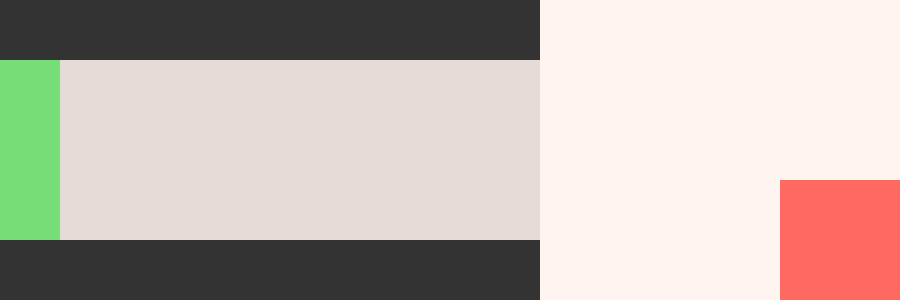

In [8]:
import numpy as np
from PIL import Image, ImageDraw

# 1. Setup the Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. Settings
cell_size = 60
rows, cols = mask.shape

# Revised Palette
colors = {
    'wall':           (51, 51, 51),    # Dark Grey
    'shelter':        (119, 221, 119), # Pastel Green
    'threat':         (255, 105, 97),  # Pastel Red
    # Split floor colors
    'floor_corridor': (230, 220, 215), # Light Grey
    'floor_chamber':  (255, 245, 240)  # Bright White
}

# 3. Create Image Canvas
img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
draw = ImageDraw.Draw(img)

# 4. Draw the Grid
for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        
        # Determine Color Priority: Wall -> Shelter -> Threat -> Floor Zone
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:      # Shelter
            fill = colors['shelter']
        elif c >= 13 and r >= 3:          # Threat
            fill = colors['threat']
        else:
            # It's floor, check zone based on column index
            # Columns 0-8 are corridor, 9-14 are chamber
            if c <= 8:
                fill = colors['floor_corridor']
            else:
                fill = colors['floor_chamber']
            
        # Draw borderless rectangle (removed outline argument)
        draw.rectangle([x0, y0, x1, y1], fill=fill)

# 5. Display
img

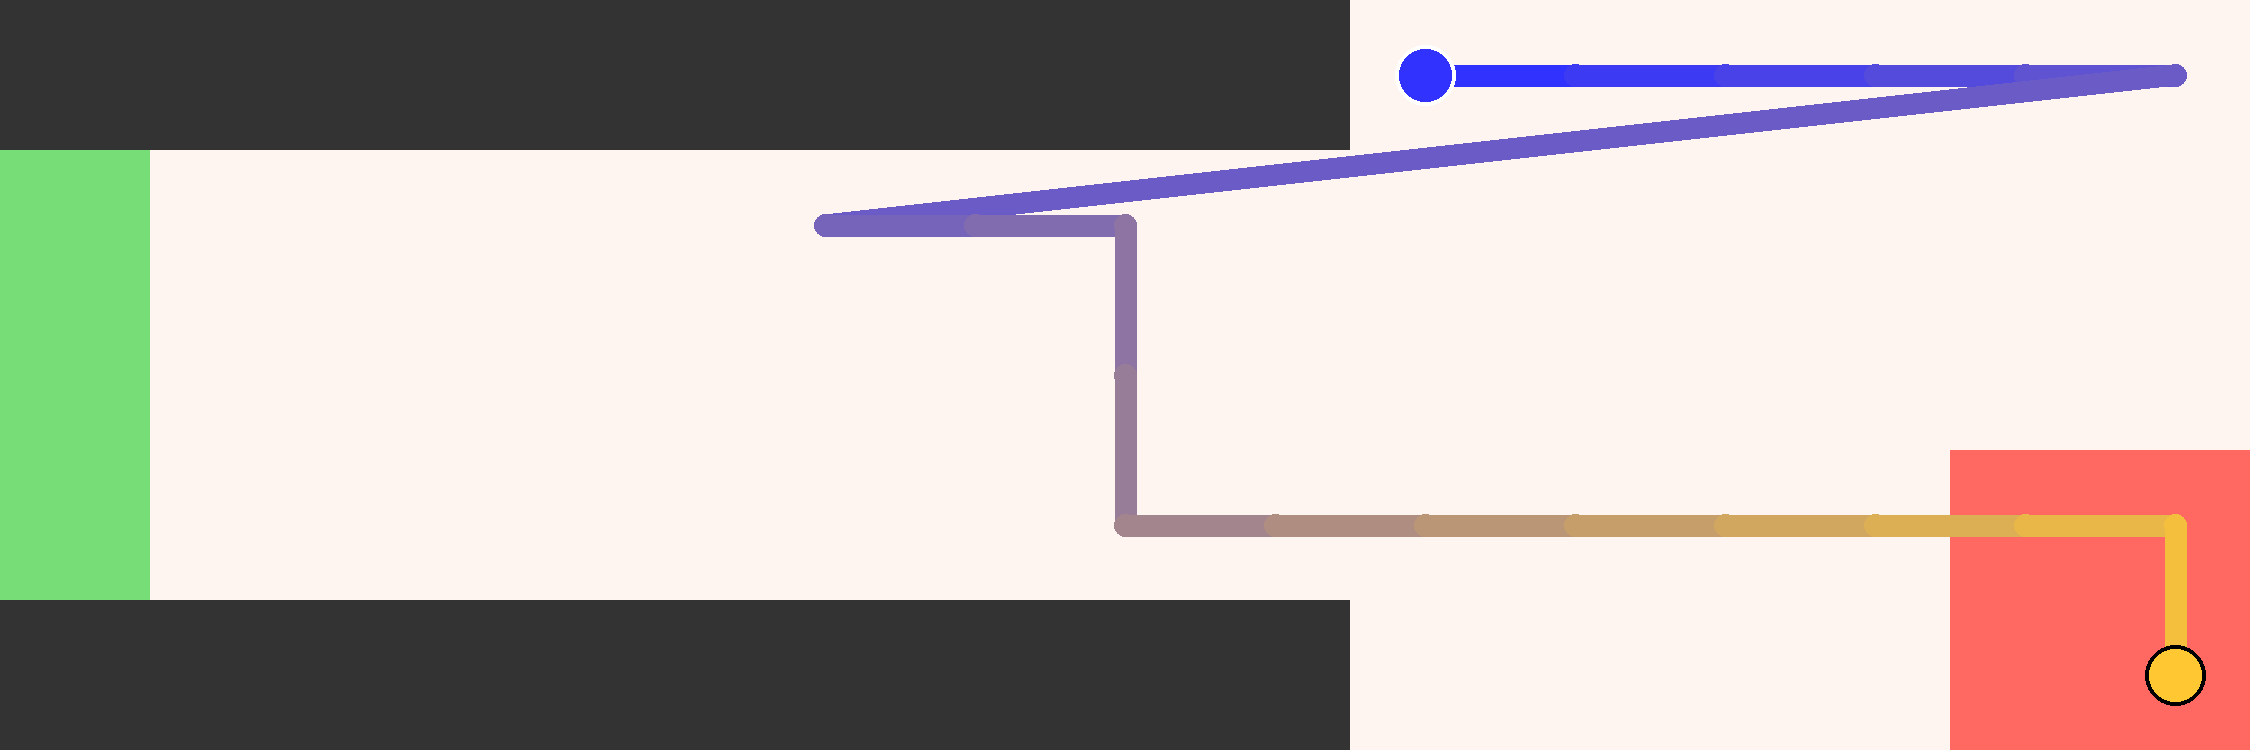

In [9]:
import numpy as np
from PIL import Image, ImageDraw

# 1. Setup Mask
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

# 2. HIGH RES SETTINGS
cell_size = 150  # Increased from 60 to 150 for sharp resolution
rows, cols = mask.shape

# Scale graphical elements based on cell_size
line_width = int(cell_size * 0.15)  # Thick trace line
joint_radius = line_width // 2      # Smooth joints
marker_radius = int(cell_size * 0.2) # Start/End dots

# 3. Colors
colors = {
    'wall':    (51, 51, 51),
    'floor':   (255, 245, 240), # Uniform Grey
    'shelter': (119, 221, 119),
    'threat':  (255, 105, 97),
    'start':   (50, 50, 255),   # Blue
    'end':     (255, 200, 50)   # Yellow
}

# 4. Coordinate Mapping
idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

# 5. Define Trajectory
example_trajectory = [
    0, 1, 2, 3, 4, 5,              
    11, 12, 13, 28, 43, 44,        
    45, 46, 47, 48, 49, 50, 56     
]

# 6. Helper: Gradient Color
def get_gradient_color(progress, start_rgb, end_rgb):
    r = int(start_rgb[0] + (end_rgb[0] - start_rgb[0]) * progress)
    g = int(start_rgb[1] + (end_rgb[1] - start_rgb[1]) * progress)
    b = int(start_rgb[2] + (end_rgb[2] - start_rgb[2]) * progress)
    return (r, g, b)

# 7. Draw Base Arena
img = Image.new('RGB', (cols * cell_size, rows * cell_size), colors['wall'])
draw = ImageDraw.Draw(img)

for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        
        if not mask[r, c]:
            fill = colors['wall']
        elif c == 0 and 1 <= r <= 3:
            fill = colors['shelter']
        elif c >= 13 and r >= 3:
            fill = colors['threat']
        else:
            fill = colors['floor']
            
        draw.rectangle([x0, y0, x1, y1], fill=fill)

# 8. Draw High-Res Trajectory
if len(example_trajectory) > 1:
    points = []
    for idx in example_trajectory:
        r, c = idx_to_rc[idx]
        px = c * cell_size + cell_size // 2
        py = r * cell_size + cell_size // 2
        points.append((px, py))

    num_segments = len(points) - 1
    for i in range(num_segments):
        progress = i / max(1, num_segments)
        color = get_gradient_color(progress, colors['start'], colors['end'])
        
        p1 = points[i]
        p2 = points[i+1]
        
        # Draw Line
        draw.line([p1, p2], fill=color, width=line_width)
        
        # Draw Smooth Joint (Circle)
        # This covers the gaps between jagged line segments
        draw.ellipse([p1[0]-joint_radius, p1[1]-joint_radius, 
                      p1[0]+joint_radius, p1[1]+joint_radius], fill=color)

    # Markers (Start/End)
    start_pt = points[0]
    end_pt = points[-1]
    
    # Start (Blue with White Border)
    draw.ellipse([start_pt[0]-marker_radius, start_pt[1]-marker_radius, 
                  start_pt[0]+marker_radius, start_pt[1]+marker_radius], 
                 fill=colors['start'], outline=(255,255,255), width=int(cell_size*0.03))
    
    # End (Yellow with Black Border)
    draw.ellipse([end_pt[0]-marker_radius, end_pt[1]-marker_radius, 
                  end_pt[0]+marker_radius, end_pt[1]+marker_radius], 
                 fill=colors['end'], outline=(0,0,0), width=int(cell_size*0.03))

# Resize for display in notebook if needed, or keep high-res
# img.resize((cols*60, rows*60), resample=Image.LANCZOS) # Optional: Scale down for preview
img

/tmp/ipykernel_3030/3806466327.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('inferno')


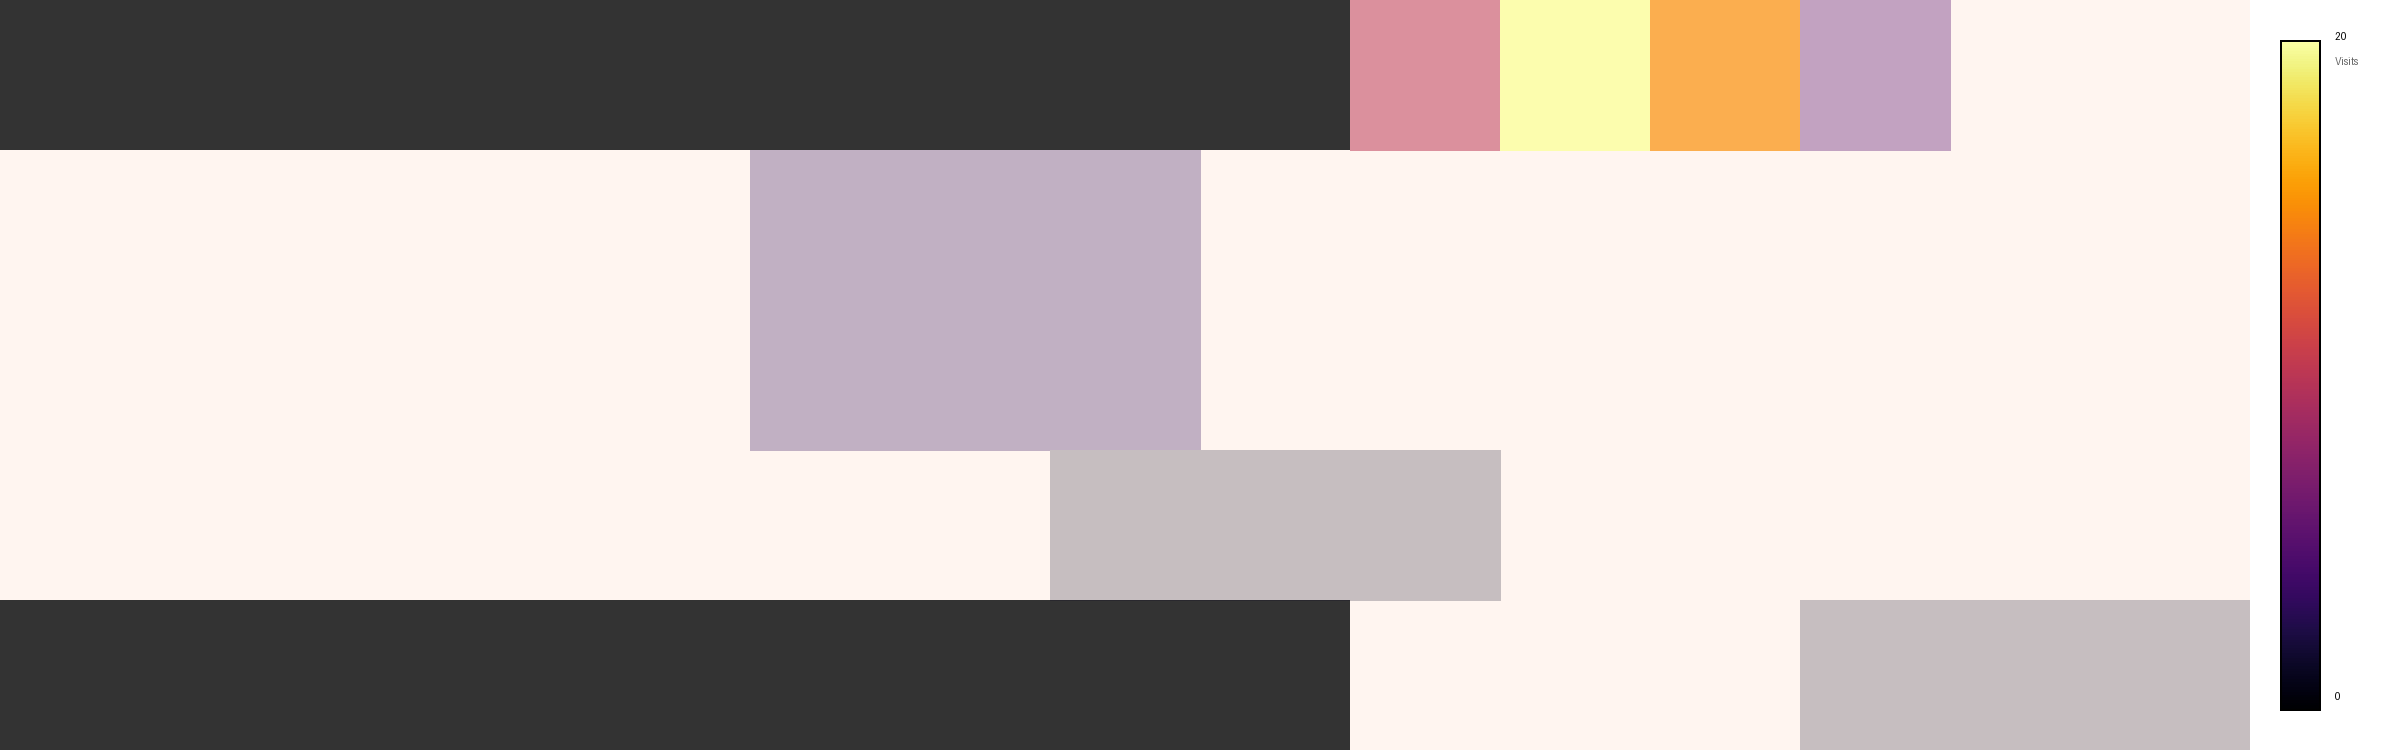

In [10]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from collections import Counter
import matplotlib.cm as cm

# 1. Setup Mask & Constants
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

cell_size = 150
rows, cols = mask.shape

# Colors
c_wall = (51, 51, 51)
c_floor = (255, 245, 240)

# 2. Trajectory & Counts
# Using the same example data
idx_to_rc = {}
counter = 0
for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            idx_to_rc[counter] = (r, c)
            counter += 1

example_trajectory = (
    [0, 1, 2, 1, 0, 1, 2, 3, 2, 1] * 5 + 
    [11, 12, 13, 28, 27, 26] * 3 +       
    [43, 44, 45, 56, 55, 54] * 1          
)

visit_counts = Counter(example_trajectory)
max_visits = max(visit_counts.values()) if visit_counts else 1

# 3. Draw Grid (Same as before)
base_img = Image.new('RGB', (cols * cell_size, rows * cell_size), c_wall)
base_draw = ImageDraw.Draw(base_img)

for r in range(rows):
    for c in range(cols):
        x0, y0 = c * cell_size, r * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        if not mask[r, c]:
            base_draw.rectangle([x0, y0, x1, y1], fill=c_wall, outline=None)
        else:
            base_draw.rectangle([x0, y0, x1, y1], fill=c_floor, outline=None)

# 4. Heatmap Overlay
overlay_img = Image.new('RGBA', base_img.size, (0,0,0,0))
overlay_draw = ImageDraw.Draw(overlay_img)
colormap = cm.get_cmap('inferno')

for idx, count in visit_counts.items():
    r, c = idx_to_rc[idx]
    x0, y0 = c * cell_size, r * cell_size
    intensity = count / max_visits
    rgba_float = colormap(intensity)
    r_val, g_val, b_val = [int(x*255) for x in rgba_float[:3]]
    alpha_val = int(50 + (intensity * 170))
    
    inset = 0
    overlay_draw.rectangle([x0+inset, y0+inset, x0+cell_size-inset, y0+cell_size-inset], 
                           fill=(r_val, g_val, b_val, alpha_val))

grid_img = Image.alpha_composite(base_img.convert('RGBA'), overlay_img)

# --- 5. CREATE LEGEND BAR ---
legend_width = 150  # Width of the side panel
bar_width = 40      # Width of the colored gradient strip
padding = 40        # Top/Bottom padding for the strip

# Create Legend Canvas
legend_img = Image.new('RGB', (legend_width, grid_img.height), (255, 255, 255))
legend_draw = ImageDraw.Draw(legend_img)

# Draw Gradient Strip
bar_height = grid_img.height - (padding * 2)
bar_x = 30 # X position of the bar
bar_y_start = padding

# We draw the gradient line by line
for y in range(bar_height):
    # Normalized height (0.0 at bottom, 1.0 at top)
    progress = 1.0 - (y / bar_height) # Inverted so Hot/Top is at the top
    
    # Get color from same colormap
    rgba = colormap(progress)
    color = tuple(int(c * 255) for c in rgba[:3])
    
    # Draw 1px horizontal line
    legend_draw.line(
        [(bar_x, bar_y_start + y), (bar_x + bar_width, bar_y_start + y)], 
        fill=color
    )

# Draw Outline around bar
legend_draw.rectangle(
    [bar_x, bar_y_start, bar_x + bar_width, bar_y_start + bar_height], 
    outline=(0,0,0), width=2
)

# Add Text Labels
try:
    # Try to load a nicer font, fallback to default
    font = ImageFont.truetype("arial.ttf", 30)
    font_title = ImageFont.truetype("arial.ttf", 24)
except IOError:
    font = ImageFont.load_default()
    font_title = ImageFont.load_default()

# Label Positions
text_x = bar_x + bar_width + 15

# "Max" Label
legend_draw.text((text_x, bar_y_start - 10), f"{max_visits}", fill=(0,0,0), font=font)
legend_draw.text((text_x, bar_y_start + 15), "Visits", fill=(100,100,100), font=font_title)

# "0" Label
legend_draw.text((text_x, bar_y_start + bar_height - 20), "0", fill=(0,0,0), font=font)

# --- 6. COMBINE GRID + LEGEND ---
final_w = grid_img.width + legend_img.width
final_h = grid_img.height
final_composite = Image.new('RGB', (final_w, final_h))
final_composite.paste(grid_img, (0, 0))
final_composite.paste(legend_img, (grid_img.width, 0))

final_composite

/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3301/3741089154.py:123: F

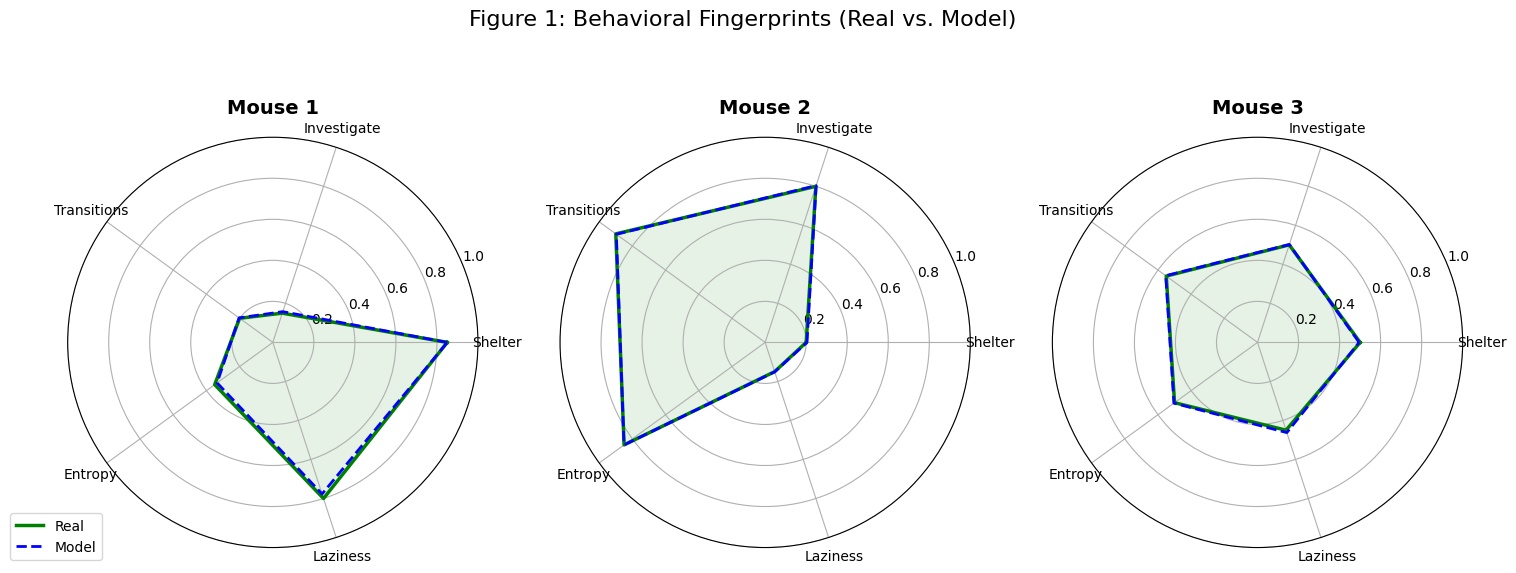

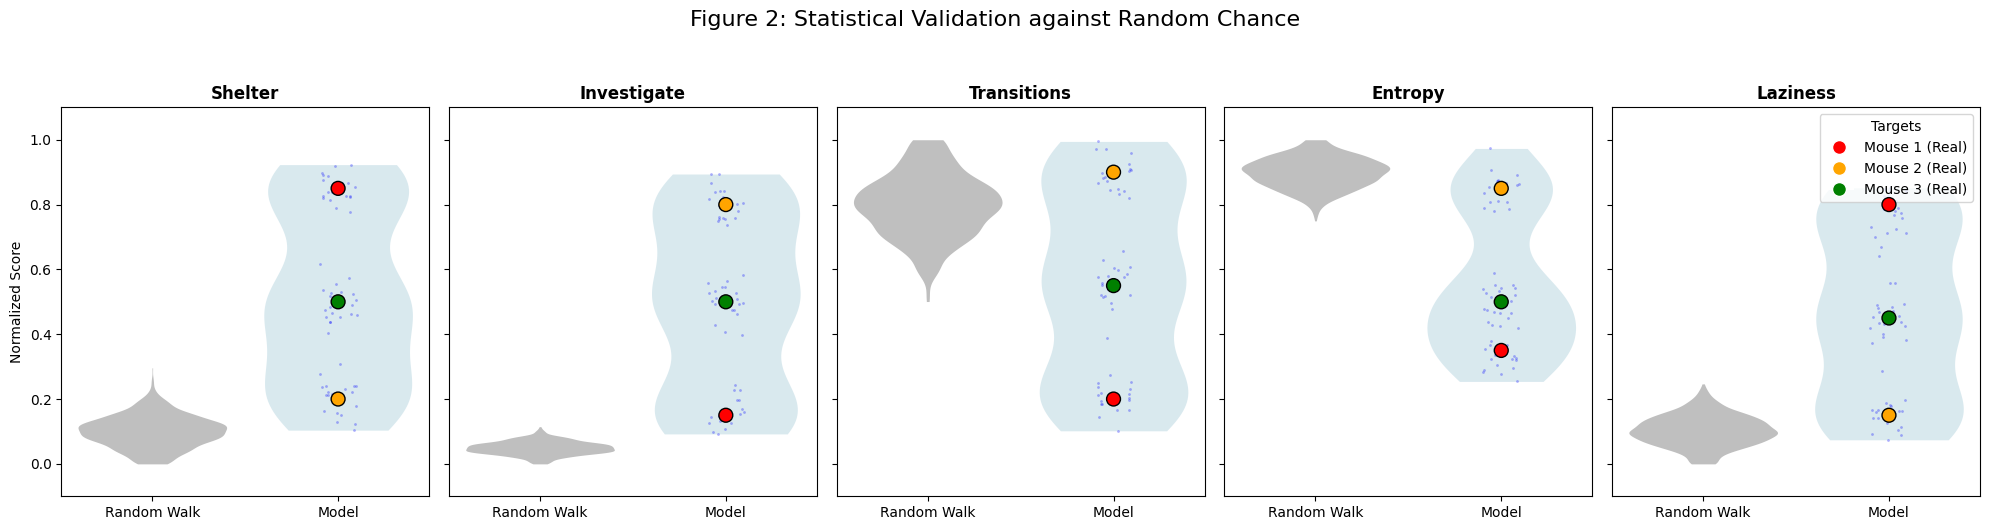

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from random_sim import random_metrics

# ==========================================
# 1. DATA GENERATION
# ==========================================
# Seed for reproducibility
np.random.seed(42)

# Metrics
metrics = ['Shelter', 'Investigate', 'Transitions', 'Entropy', 'Laziness']
num_vars = len(metrics)

# --- A. Real Mouse Data (N=3 distinct phenotypes) ---
# Mouse 1: "Anxious" (High Shelter, Low Investigate)
real_m1 = [0.85, 0.15, 0.20, 0.35, 0.80]
# Mouse 2: "Curious" (Low Shelter, High Investigate)
real_m2 = [0.20, 0.80, 0.90, 0.85, 0.15]
# Mouse 3: "Balanced" (Moderate everything)
real_m3 = [0.50, 0.50, 0.55, 0.50, 0.45]

real_data_map = {
    'Mouse 1': real_m1,
    'Mouse 2': real_m2,
    'Mouse 3': real_m3
}

# --- B. Model Data (N=3 Mice * 20 Runs each) ---
# Simulating stochastic variation around the "true" phenotype
model_data = []
for m_label, m_vals in real_data_map.items():
    for _ in range(20): # 20 runs per mouse
        # Add slight noise to simulate generative stochasticity
        noisy_vals = np.clip([v + np.random.normal(0, 0.05) for v in m_vals], 0, 1)
        model_data.append({'Mouse': m_label, 'Values': noisy_vals})

# --- C. Random Walk Data (N=1000 Baseline runs) ---
# Simulating a null distribution (e.g., high entropy, low shelter preference)
rw_data = []
for _ in range(1000):
    # Random walks tend to be diffusive (High Entropy) and non-specific (Low Investigate)
    rw_vals = [
        np.random.normal(0.10, 0.05), # Shelter (Chance)
        np.random.normal(0.05, 0.02), # Investigate (Chance)
        np.random.normal(0.80, 0.10), # Transitions (High/Diffusive)
        np.random.normal(0.90, 0.05), # Entropy (Maximal)
        np.random.normal(0.10, 0.05)  # Laziness (Low)
    ]
    rw_data.append(np.clip(rw_vals, 0, 1))

rw_data_dict = random_metrics(1000)

# ==========================================
# 2. PLOT 1: RADAR CHARTS (Fingerprints)
# ==========================================
# Helper to close the polygon loop
def close_loop(data):
    return np.concatenate((data, [data[0]]))

# Compute angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.concatenate((angles, [angles[0]]))

fig1, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))
fig1.suptitle('Figure 1: Behavioral Fingerprints (Real vs. Model)', fontsize=16, y=1.05)

mice_list = [('Mouse 1', real_m1), ('Mouse 2', real_m2), ('Mouse 3', real_m3)]

for ax, (name, real_vals) in zip(axes.flat, mice_list):
    # 1. Plot Real Data (Solid Line)
    ax.plot(angles_closed, close_loop(real_vals), color='green', linewidth=2.5, label='Real')
    ax.fill(angles_closed, close_loop(real_vals), color='green', alpha=0.1)
    
    # 2. Plot Model Mean (Dashed Line)
    # Get mean of model runs for this mouse
    m_runs = [d['Values'] for d in model_data if d['Mouse'] == name]
    m_mean = np.mean(m_runs, axis=0)
    ax.plot(angles_closed, close_loop(m_mean), color='blue', linewidth=2, linestyle='--', label='Model')
    
    # Formatting
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_title(name, weight='bold', size=14, position=(0.5, 1.1))
    ax.set_ylim(0, 1)

# Add Legend to first plot
axes[0].legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# ==========================================
# 3. PLOT 2: COMPARATIVE VIOLIN PLOTS (Cognitive Gap)
# ==========================================
# Prepare DataFrame for Seaborn
rows = []

# Add Random Walk Data
for vals in rw_data:
    for i, metric in enumerate(metrics):
        rows.append({'Metric': metric, 'Value': vals[i], 'Type': 'Random Walk', 'Mouse': 'RW'})

# Add Model Data
for item in model_data:
    for i, metric in enumerate(metrics):
        rows.append({'Metric': metric, 'Value': item['Values'][i], 'Type': 'Model', 'Mouse': item['Mouse']})

# Add Real Data
for name, vals in real_data_map.items():
    for i, metric in enumerate(metrics):
        rows.append({'Metric': metric, 'Value': vals[i], 'Type': 'Real', 'Mouse': name})

df = pd.DataFrame(rows)

# Create Plot
fig2, axes2 = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
fig2.suptitle('Figure 2: Statistical Validation against Random Chance', fontsize=16, y=1.05)

colors = {'Random Walk': 'grey', 'Model': 'lightblue', 'Real': 'green'}

for i, metric in enumerate(metrics):
    ax = axes2[i]
    subset = df[df['Metric'] == metric]
    
    # 1. Violin Plots for Distributions (RW and Model)
    sns.violinplot(
        data=subset[subset['Type'].isin(['Random Walk', 'Model'])],
        x='Type', y='Value',
        palette=colors, ax=ax,
        inner=None, linewidth=0, alpha=0.5, cut=0
    )
    
    # 2. Strip Plot for Model (to show particle density)
    sns.stripplot(
        data=subset[subset['Type'] == 'Model'],
        x='Type', y='Value',
        color='blue', size=2, alpha=0.3, jitter=True, ax=ax
    )

    # 3. Large Dots for Real Mice (The Ground Truths)
    # We plot them over the "Model" column to show fit
    real_subset = subset[subset['Type'] == 'Real']
    # We map x=1 because "Model" is at index 1 in the violin plot (0=RW, 1=Model)
    ax.scatter(
        x=[1]*len(real_subset), 
        y=real_subset['Value'], 
        c=['red', 'orange', 'green'], # Distinct colors for Mouse 1, 2, 3
        s=100, zorder=10, edgecolors='black', label='Real Mice'
    )

    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Score' if i==0 else '')
    ax.set_ylim(-0.1, 1.1)

# Add custom legend for the real mice dots
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Mouse 1 (Real)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Mouse 2 (Real)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Mouse 3 (Real)')
]
axes2[-1].legend(handles=legend_elements, loc='upper right', title="Targets")

plt.tight_layout()
plt.show()

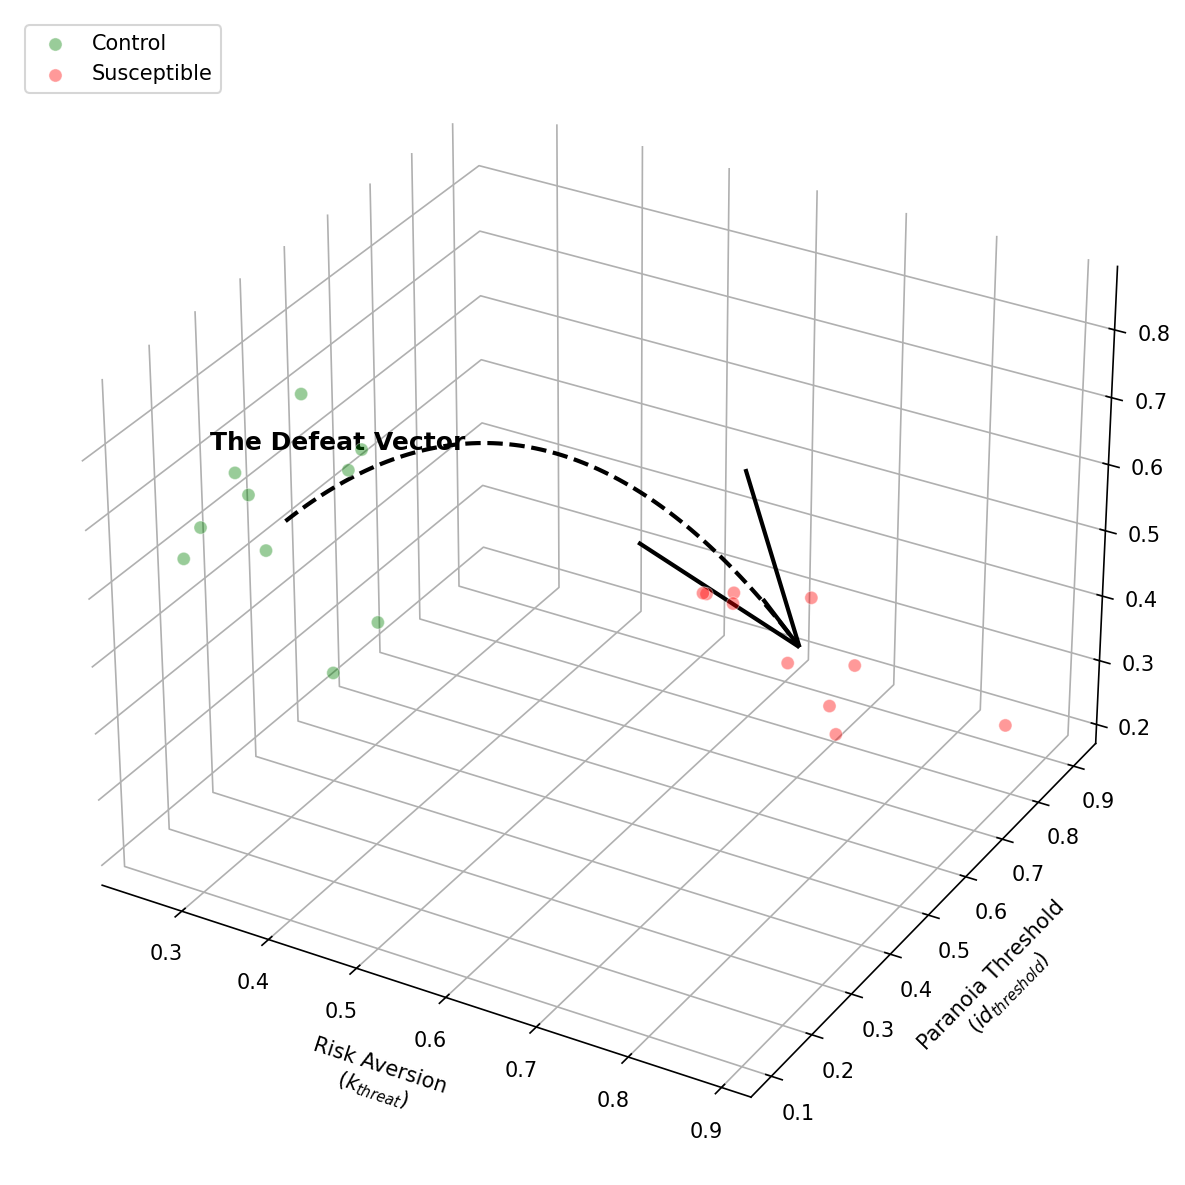

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_bezier_curve(p0, p1, p2, num_points=100):
    """
    Returns x, y, z coordinates for a quadratic Bezier curve.
    p0: Start point (array)
    p1: Control point (determines the arch)
    p2: End point (array)
    """
    t = np.linspace(0, 1, num_points)
    # Reshape t for broadcasting: (num_points, 1)
    t = t[:, np.newaxis]
    
    # Quadratic Bezier formula: B(t) = (1-t)^2 * P0 + 2(1-t)t * P1 + t^2 * P2
    curve = (1 - t)**2 * p0 + 2 * (1 - t) * t * p1 + t**2 * p2
    return curve[:, 0], curve[:, 1], curve[:, 2]

# --- 1. GENERATE DUMMY DATA ---
# Replace these blocks with your actual data later
np.random.seed(42) # For reproducibility

# "Control" group (Green): Higher Info Gain, Lower Paranoia
n_control = 10
ctrl_x = np.random.normal(loc=0.3, scale=0.1, size=n_control) # k_threat
ctrl_y = np.random.normal(loc=0.3, scale=0.1, size=n_control) # id_threshold
ctrl_z = np.random.normal(loc=0.7, scale=0.1, size=n_control) # sensory_prec_slope

# "Susceptible" group (Red): Lower Info Gain, Higher Paranoia
n_suscept = 10
susp_x = np.random.normal(loc=0.7, scale=0.1, size=n_suscept) # k_threat
susp_y = np.random.normal(loc=0.8, scale=0.1, size=n_suscept) # id_threshold
susp_z = np.random.normal(loc=0.3, scale=0.1, size=n_suscept) # sensory_prec_slope

# --- 2. CALCULATE CENTROIDS & CURVE ---
# Centroids
c_start = np.array([np.mean(ctrl_x), np.mean(ctrl_y), np.mean(ctrl_z)])
c_end   = np.array([np.mean(susp_x), np.mean(susp_y), np.mean(susp_z)])

# Control Point for the Bezier Curve (The "Arch")
# We take the midpoint and add an offset to Z (and slightly to Y) to make it curve "up"
midpoint = (c_start + c_end) / 2
curve_height = 0.4 
control_point = midpoint + np.array([0, 0, curve_height]) 

# Generate the curve coordinates
lx, ly, lz = get_bezier_curve(c_start, control_point, c_end)

# --- 3. SETUP PLOT ---
fig = plt.figure(figsize=(10, 8), dpi=150) # High DPI for paper quality
ax = fig.add_subplot(111, projection='3d')

# --- 4. PLOT SCATTER CLOUDS ---
# Alpha controls transparency (0.0 to 1.0)
ax.scatter(ctrl_x, ctrl_y, ctrl_z, c='green', s=40, alpha=0.4, 
           edgecolor='white', linewidth=0.5, label='Control')
ax.scatter(susp_x, susp_y, susp_z, c='red', s=40, alpha=0.4, 
           edgecolor='white', linewidth=0.5, label='Susceptible')

# --- 5. PLOT THE "DEFEAT VECTOR" ---
# A. Draw the curved line
ax.plot(lx, ly, lz, color='black', linewidth=2, linestyle='--')

# B. Draw the arrow head at the end
# We calculate the direction vector from the last two points of the curve
direction = np.array([lx[-1] - lx[-2], ly[-1] - ly[-2], lz[-1] - lz[-2]])
# Normalize the direction length for the quiver
length = np.linalg.norm(direction)
direction = direction / length 

# Add the arrow cone (quiver)
# pivot='tip' places the tip of the arrow at the exact end coordinate
ax.quiver(lx[-1], ly[-1], lz[-1], 
          direction[0], direction[1], direction[2], 
          length=0.1, color='black', linewidth=2, arrow_length_ratio=3, pivot='tip')

# C. Add the label floating near the apex of the curve
ax.text(lx[10], ly[10], lz[10] + 0.05, "The Defeat Vector", 
        color='black', fontsize=12, fontweight='bold', ha='center')

# --- 6. COSMETICS & LABELS ---
ax.set_xlabel('Risk Aversion\n($k_{threat}$)', fontsize=10, labelpad=10)
ax.set_ylabel('Paranoia Threshold\n($id_{threshold}$)', fontsize=10, labelpad=10)
ax.set_zlabel('Info Gain Rate\n(slope)', fontsize=10, labelpad=10)

# Clean up panels (remove gray background for publication)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Set a nice viewing angle
ax.view_init(elev=30, azim=-60)

plt.legend(loc='upper left')
plt.tight_layout()

# Save command (commented out)
# plt.savefig('defeat_vector_3d.pdf', transparent=True)

plt.show()

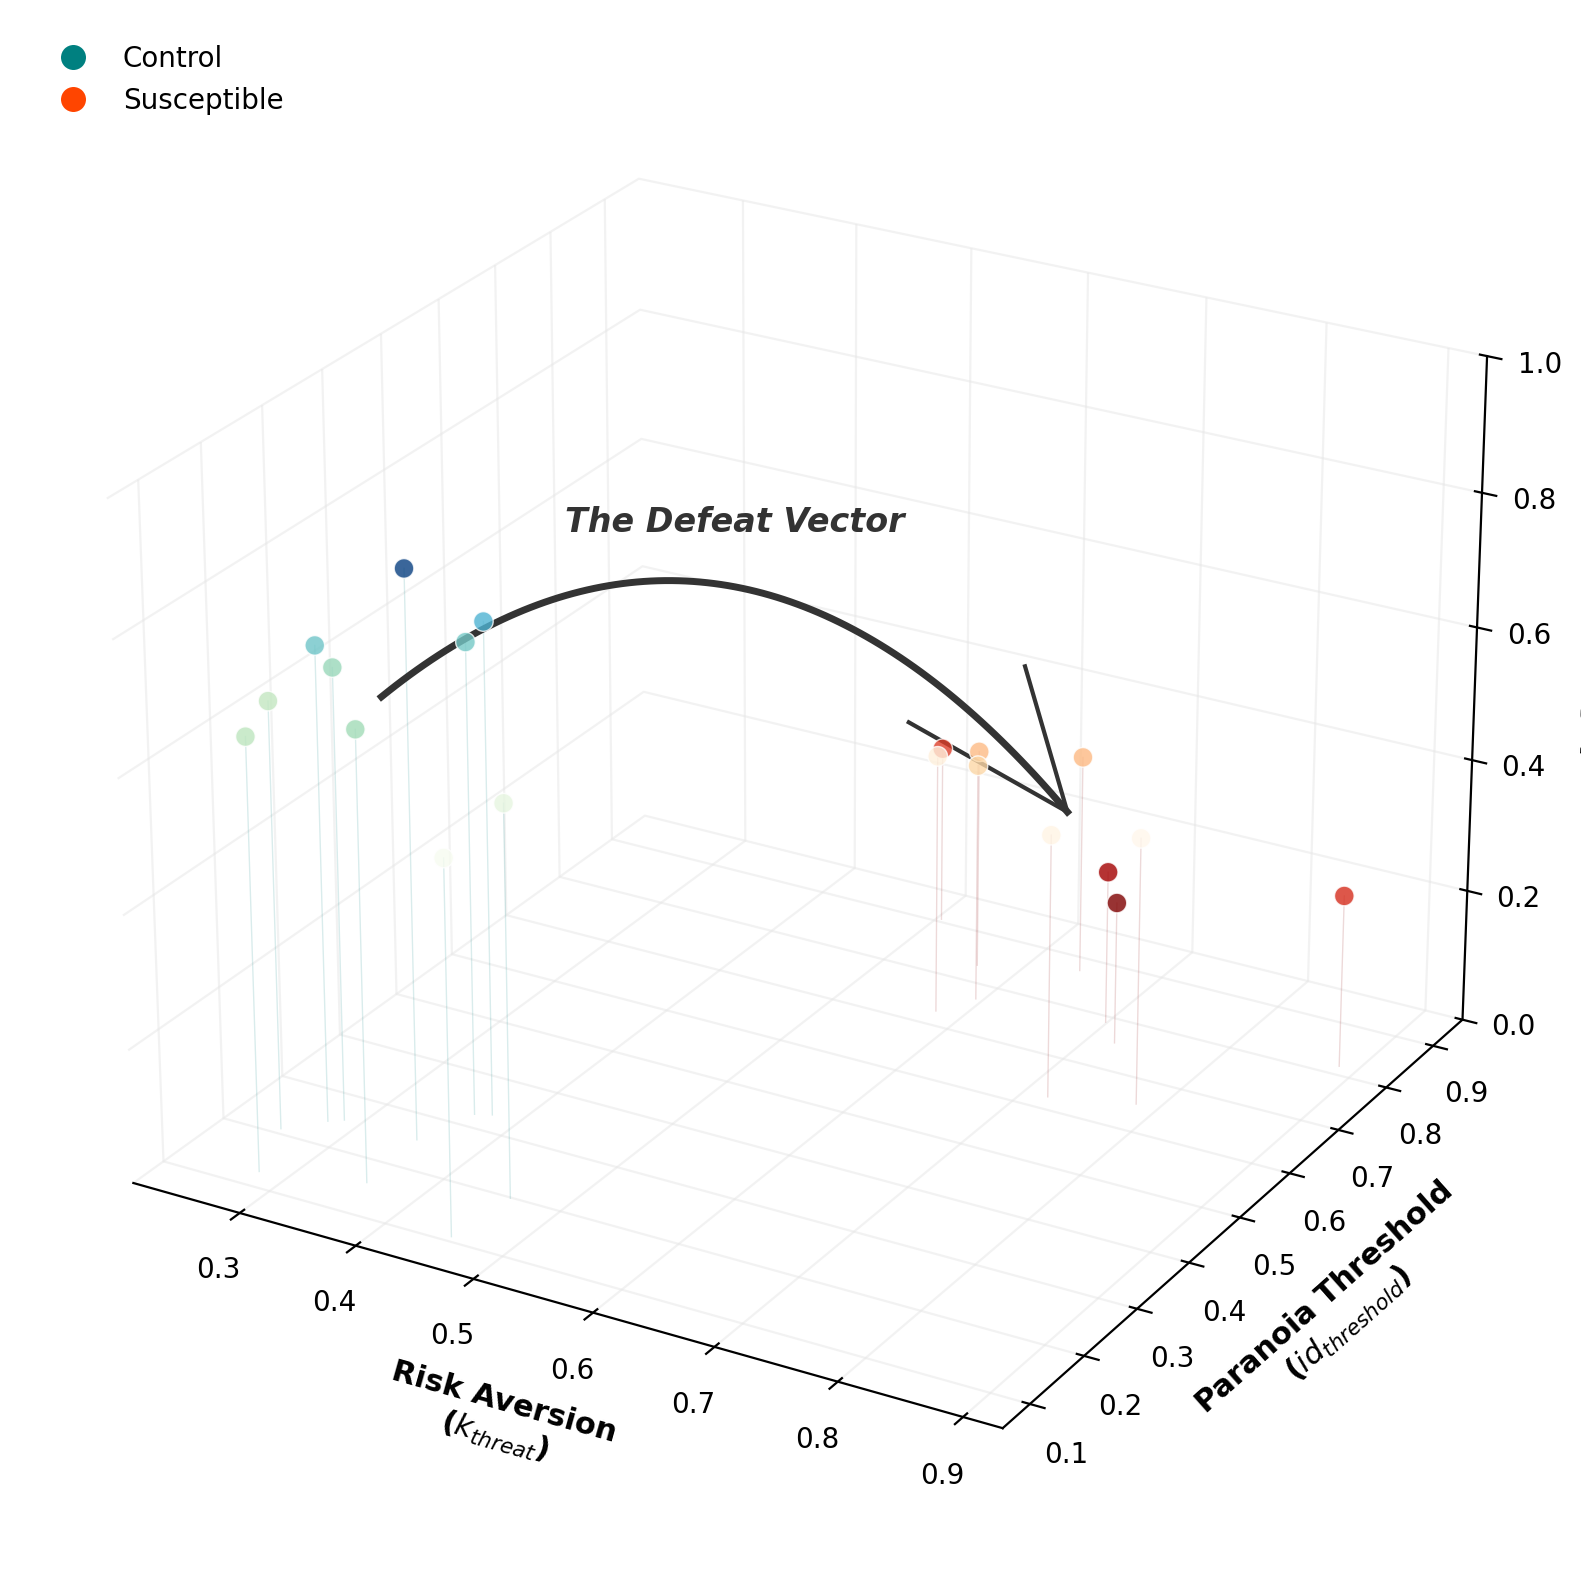

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_bezier_curve(p0, p1, p2, num_points=100):
    t = np.linspace(0, 1, num_points)[:, np.newaxis]
    curve = (1 - t)**2 * p0 + 2 * (1 - t) * t * p1 + t**2 * p2
    return curve[:, 0], curve[:, 1], curve[:, 2]

# --- 1. GENERATE DUMMY DATA ---
np.random.seed(42)
n_points = 10

# Control (High Info Gain, Low Paranoia)
ctrl_x = np.random.normal(0.3, 0.1, n_points) 
ctrl_y = np.random.normal(0.3, 0.1, n_points)
ctrl_z = np.random.normal(0.7, 0.1, n_points)

# Susceptible (Low Info Gain, High Paranoia)
susp_x = np.random.normal(0.7, 0.1, n_points)
susp_y = np.random.normal(0.8, 0.1, n_points)
susp_z = np.random.normal(0.3, 0.1, n_points)

# --- 2. CALCULATE GEOMETRY ---
c_start = np.array([np.mean(ctrl_x), np.mean(ctrl_y), np.mean(ctrl_z)])
c_end   = np.array([np.mean(susp_x), np.mean(susp_y), np.mean(susp_z)])

# Arch logic
midpoint = (c_start + c_end) / 2
control_point = midpoint + np.array([0, 0, 0.5]) # Lifts the arrow arch up
lx, ly, lz = get_bezier_curve(c_start, control_point, c_end)

# --- 3. STYLISH PLOTTING ---
fig = plt.figure(figsize=(10, 8), dpi=200) # High DPI
ax = fig.add_subplot(111, projection='3d')

# A. THE DROP LINES (The "Pro" Touch)
# We find the floor (z_min) to anchor our lines
z_min = 0.0
for x, y, z in zip(ctrl_x, ctrl_y, ctrl_z):
    ax.plot([x, x], [y, y], [z_min, z], color='teal', alpha=0.15, linewidth=0.5)
for x, y, z in zip(susp_x, susp_y, susp_z):
    ax.plot([x, x], [y, y], [z_min, z], color='darkred', alpha=0.15, linewidth=0.5)

# B. THE CLOUDS (Gradient Colors)
# Control: Map Z values to a "Cool" colormap (Teals)
sc1 = ax.scatter(ctrl_x, ctrl_y, ctrl_z, c=ctrl_z, cmap='GnBu', 
                 s=50, alpha=0.8, edgecolors='white', linewidth=0.5, label='Control')

# Susceptible: Map Z values to a "Warm" colormap (Oranges/Reds)
sc2 = ax.scatter(susp_x, susp_y, susp_z, c=susp_z, cmap='OrRd_r', 
                 s=50, alpha=0.8, edgecolors='white', linewidth=0.5, label='Susceptible')

# C. THE DEFEAT VECTOR (Styled)
ax.plot(lx, ly, lz, color='#333333', linewidth=2.5, linestyle='-')

# Arrow Head
direction = np.array([lx[-1] - lx[-2], ly[-1] - ly[-2], lz[-1] - lz[-2]])
length = np.linalg.norm(direction)
direction = direction / length 
ax.quiver(lx[-1], ly[-1], lz[-1], 
          direction[0], direction[1], direction[2], 
          length=0.08, color='#333333', arrow_length_ratio=3, pivot='tip', linewidth=1.5)

# D. AESTHETICS CLEANUP
# Remove gray panes for a clean "white paper" look
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Lighter grid
ax.xaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
ax.yaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)
ax.zaxis._axinfo["grid"]['color'] =  (0.9,0.9,0.9,0.5)

# Labels with Math Formatting
ax.set_xlabel('Risk Aversion\n($k_{threat}$)', fontsize=11, weight='bold', labelpad=10)
ax.set_ylabel('Paranoia Threshold\n($id_{threshold}$)', fontsize=11, weight='bold', labelpad=10)
ax.set_zlabel('Info Gain\n(slope)', fontsize=11, weight='bold', labelpad=10)

# Set limits to make sure the floor lines touch the bottom
ax.set_zlim(z_min, 1.0)

# Add label for the vector
ax.text(lx[50], ly[50], lz[50] + 0.08, "The Defeat Vector", 
        color='#333333', fontsize=12, style='italic', ha='center', weight='bold')

# Legend (Manually creating proxy artists to represent the groups generally)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Control',
                          markerfacecolor='teal', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Susceptible',
                          markerfacecolor='orangered', markersize=10)]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

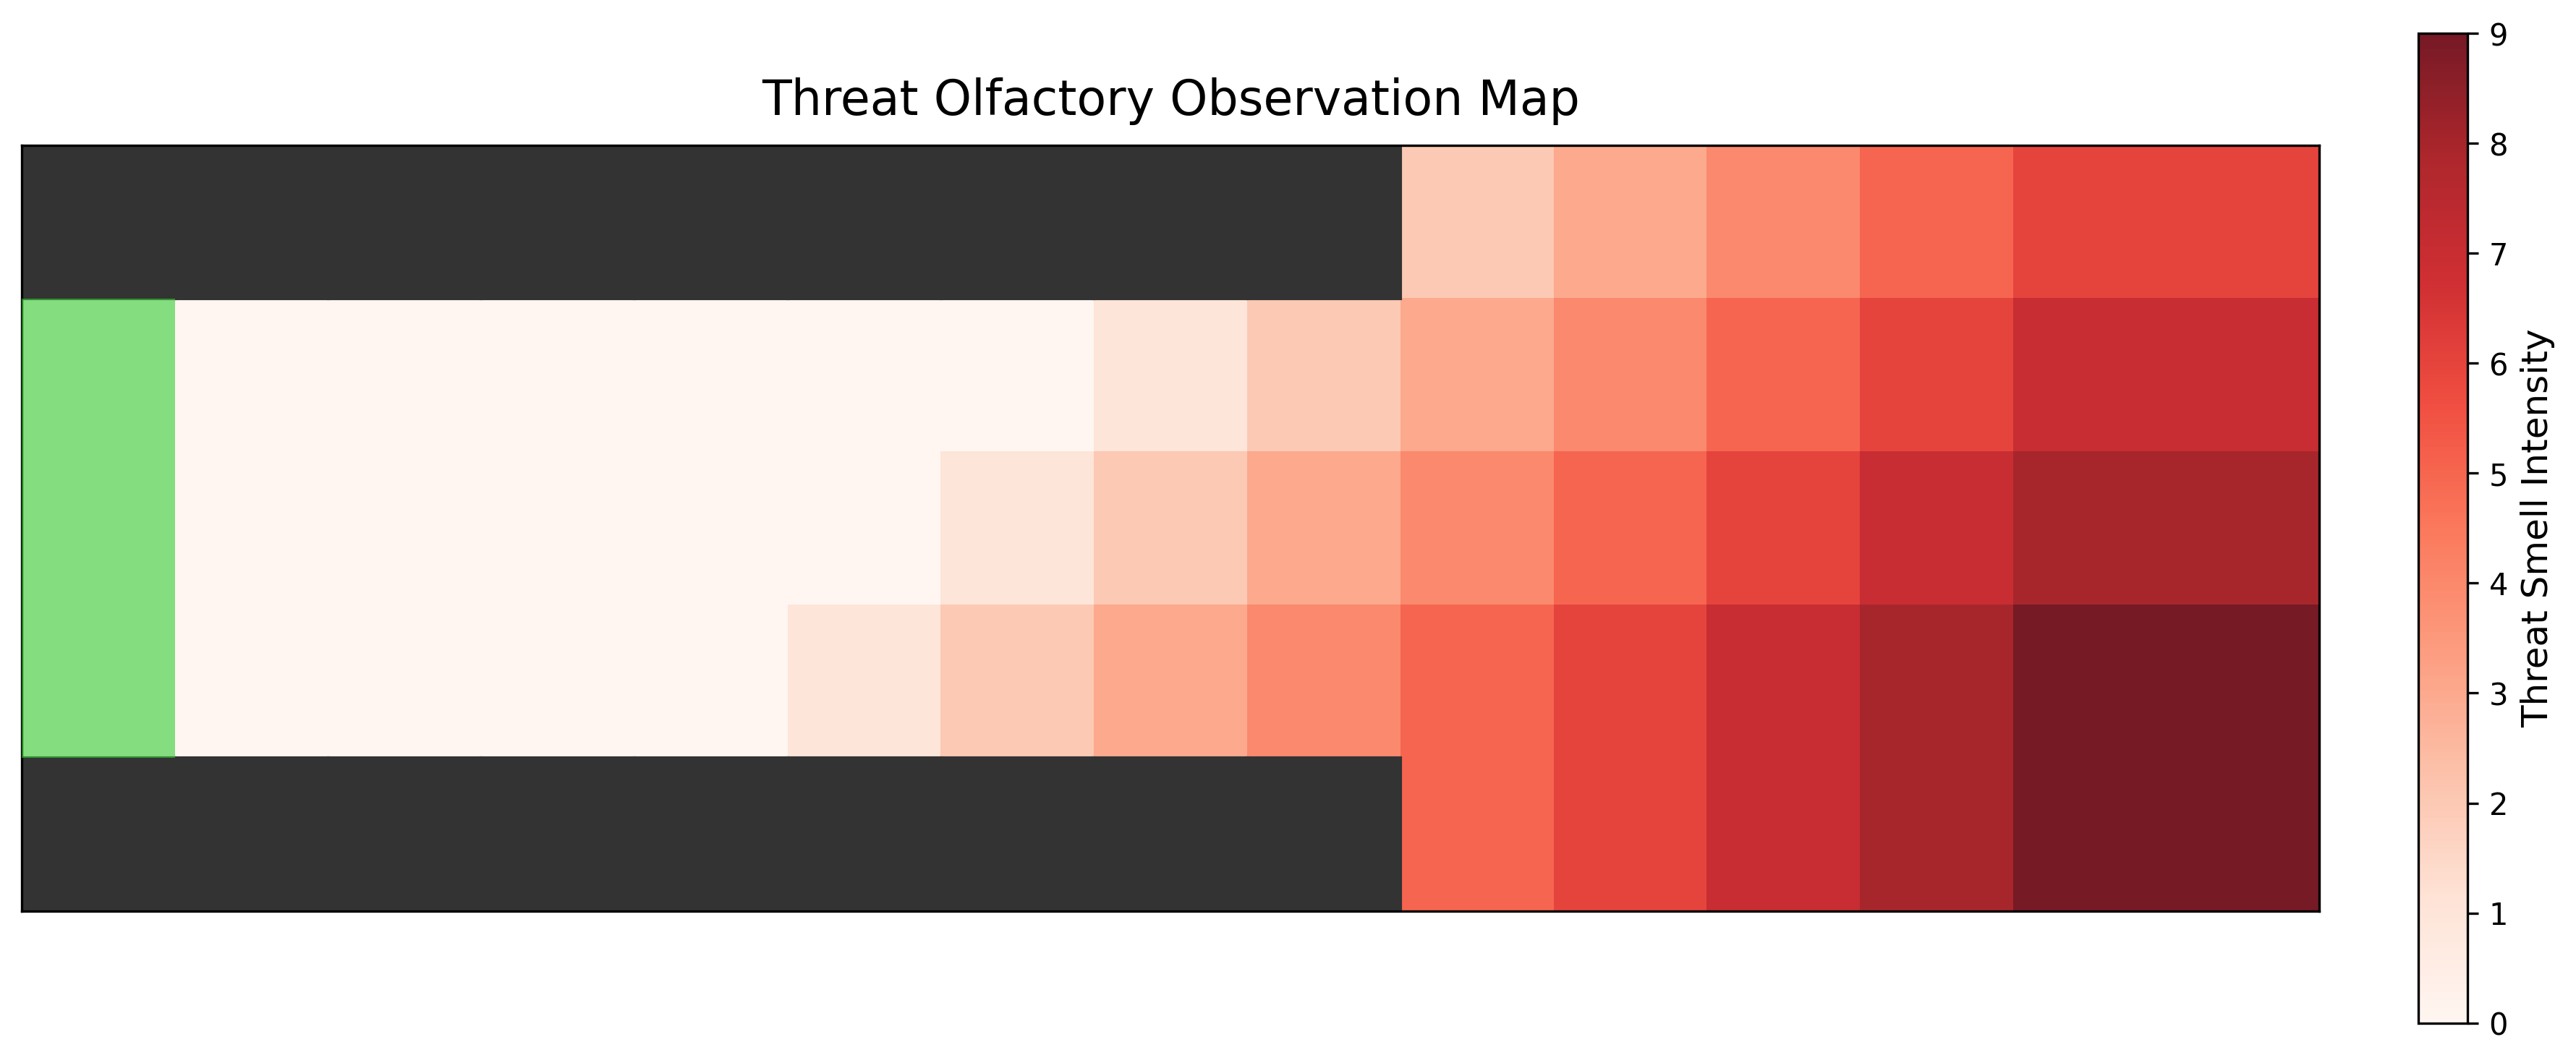

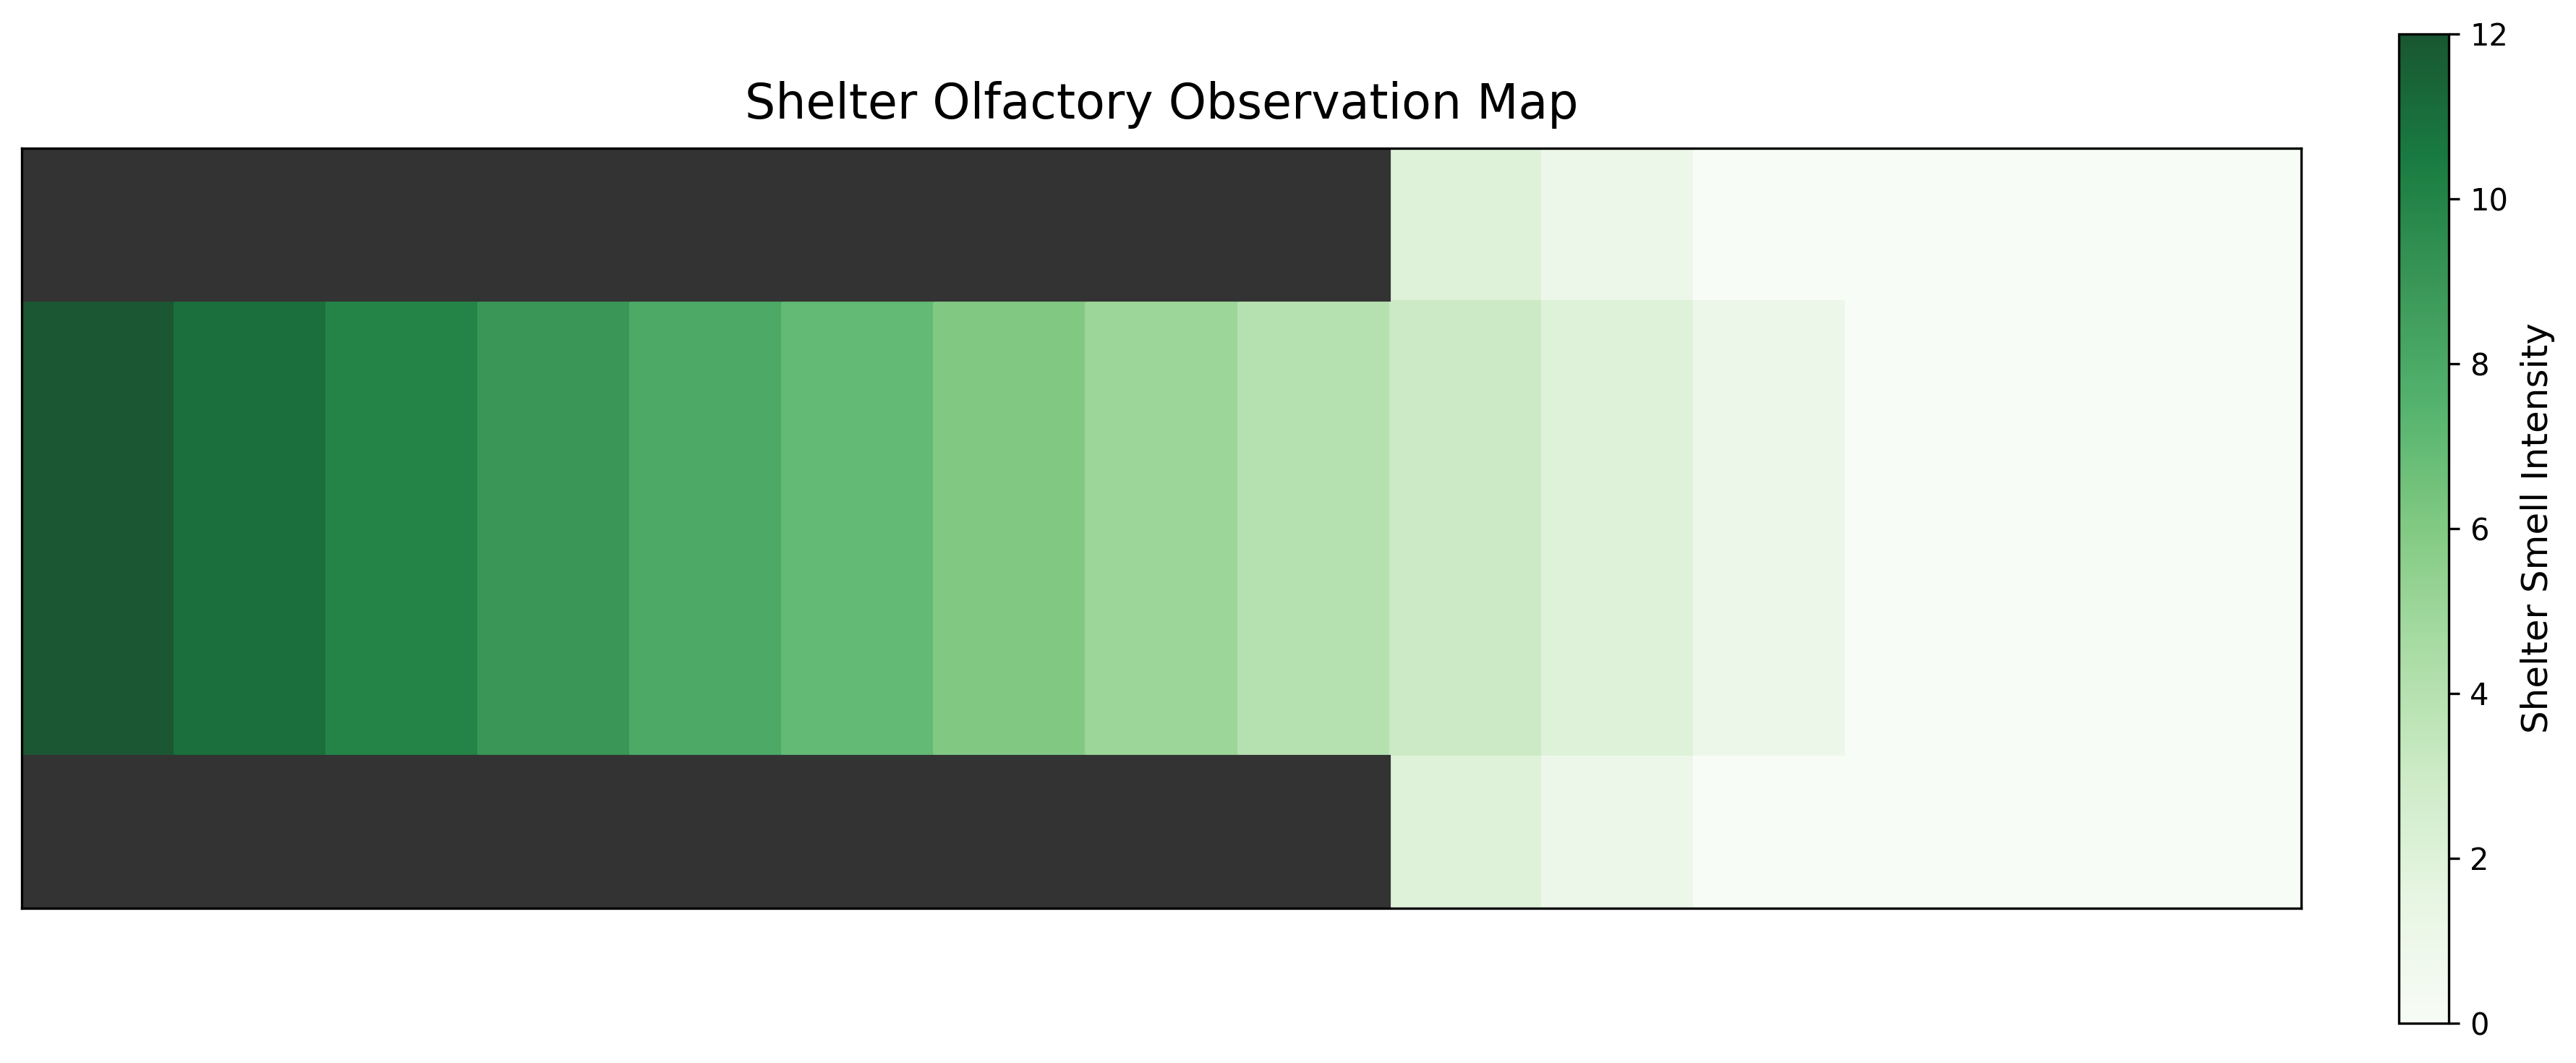

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- 1. SETUP DATA ---
mask = np.array([
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
], dtype=bool)

rows, cols = mask.shape

# Sources
shelter_cells = [(r, 0) for r in range(rows) if mask[r, 0]]
threat_cells = [(3, 13), (3, 14), (4, 13), (4, 14)]

# Compute Distances
def get_min_manhattan_dist(r, c, source_cells):
    dists = [abs(r - sr) + abs(c - sc) for (sr, sc) in source_cells]
    return min(dists)

grid_threat = np.full((rows, cols), np.nan)
grid_shelter = np.full((rows, cols), np.nan)

max_threat_intensity = 9
max_shelter_intensity = 12

for r in range(rows):
    for c in range(cols):
        if mask[r, c]:
            # Threat
            dist_t = get_min_manhattan_dist(r, c, threat_cells)
            grid_threat[r, c] = max(0, max_threat_intensity - dist_t)
            
            # Shelter
            dist_s = get_min_manhattan_dist(r, c, shelter_cells)
            grid_shelter[r, c] = max(0, max_shelter_intensity - dist_s)

# Helper for consistent styling
def setup_plot_ax(ax, rows, cols, mask):
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    # Draw walls
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c]:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, color=(0.2, 0.2, 0.2)))

# --- 2. PLOT 1: THREAT INTENSITY ---
fig1, ax1 = plt.subplots(figsize=(12, 5), dpi=300) # High Res
setup_plot_ax(ax1, rows, cols, mask)

# Heatmap
im1 = ax1.imshow(grid_threat, cmap='Reds', alpha=0.9, vmin=0, vmax=max_threat_intensity)
cbar1 = fig1.colorbar(im1, ax=ax1, fraction=0.03, pad=0.04)
cbar1.set_label('Threat Smell Intensity', fontsize=12)
cbar1.ax.tick_params(labelsize=10)

# Overlay Shelter Location (Green) for context
for (sr, sc) in shelter_cells:
    ax1.add_patch(Rectangle((sc - 0.5, sr - 0.5), 1, 1, 
                            linewidth=0, facecolor='limegreen', alpha=0.6, zorder=5))

ax1.set_title('Threat Olfactory Observation Map', fontsize=16, pad=10)
plt.tight_layout()
# plt.savefig('threat_map.png', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()

# --- 3. PLOT 2: SHELTER CUE ---
fig2, ax2 = plt.subplots(figsize=(12, 5), dpi=300) # High Res
setup_plot_ax(ax2, rows, cols, mask)

# Heatmap
im2 = ax2.imshow(grid_shelter, cmap='Greens', alpha=0.9, vmin=0, vmax=max_shelter_intensity)
cbar2 = fig2.colorbar(im2, ax=ax2, fraction=0.03, pad=0.04)
cbar2.set_label('Shelter Smell Intensity', fontsize=12)
cbar2.ax.tick_params(labelsize=10)

# (No red threat outline here, as requested)

ax2.set_title('Shelter Olfactory Observation Map', fontsize=16, pad=10)
plt.tight_layout()
# plt.savefig('shelter_map.png', bbox_inches='tight', dpi=300) # Uncomment to save
plt.show()